# Homogenization - elastic modulus at different angles

> Last modified: October 29, 2025
>
> Editor: Weipeng Xu with Copilot assistance

## Derivation

After obtaining the homogenized elasticity (stiffness) matrix $\boldsymbol C^*$, we can calculate the elastic modulus at different angles to quantify the anisotropic properties of the homogenized material. 

For simplicity, we consider a 2D case. Assuming the strain and stress vector in Voigt notation is given by
$$
\boldsymbol \varepsilon = [\varepsilon_{xx}, \varepsilon_{yy}, \gamma_{xy}]^T, \quad \boldsymbol \sigma = [\sigma_{xx}, \sigma_{yy}, \tau_{xy}]^T
$$
where $\gamma_{xy} = 2\varepsilon_{xy}$ is the engineering shear strain. To analyze the material properties at an angle $\theta$, we need to define the rotation matrix $\boldsymbol T(\theta)$ for strain and stress at an angle $\theta$. Note that the strain and stress transformation matrices are different due to the definition of engineering shear strain. The transformation matrix for strain is given by
$$
\boldsymbol T_\varepsilon(\theta) = \begin{bmatrix}
c^2 & s^2 & cs \\
s^2 & c^2 & -cs \\
-2cs & 2cs & c^2 - s^2
\end{bmatrix}
$$
and the transformation matrix for stress is given by
$$
\boldsymbol T_\sigma(\theta) = \begin{bmatrix}
c^2 & s^2 & 2cs \\
s^2 & c^2 & -2cs \\
-cs & cs & c^2 - s^2
\end{bmatrix}.
$$
where $c = \cos\theta$ and $s = \sin\theta$. Due to the conservation of energy, the transformation matrices satisfy the relation
$$
\boldsymbol T_\varepsilon(\theta) = \boldsymbol T_\sigma(\theta)^{-T}
$$

In the original coordinate system, the constitutive relation can be expressed with the homogenized stiffness matrix $\boldsymbol C^*$ or the compliance matrix $\boldsymbol S^* = (\boldsymbol C^*)^{-1}$ as
$$
\boldsymbol \sigma = \boldsymbol C^* \boldsymbol \varepsilon, \quad \boldsymbol \varepsilon = \boldsymbol S^* \boldsymbol \sigma
$$
To express the constitutive relation in the rotated coordinate system, we apply the transformation matrices:
$$
\boldsymbol \sigma' = \boldsymbol T_\sigma(\theta) \boldsymbol \sigma, \quad \boldsymbol \varepsilon' = \boldsymbol T_\varepsilon(\theta) \boldsymbol \varepsilon
$$
Substituting these relations into the original constitutive equations gives
$$
\boldsymbol T_\sigma(\theta)^{-1} \boldsymbol \sigma' = \boldsymbol C^* \boldsymbol T_\varepsilon(\theta)^{-1} \boldsymbol \varepsilon', \quad \boldsymbol T_\varepsilon(\theta)^{-1} \boldsymbol \varepsilon' = \boldsymbol S^* \boldsymbol T_\sigma(\theta)^{-1} \boldsymbol \sigma'
$$
which can be rearranged to obtain the constitutive relations in the rotated coordinate system:
$$
\boldsymbol \sigma' = \boldsymbol C' \boldsymbol \varepsilon', \quad \boldsymbol \varepsilon' = \boldsymbol S' \boldsymbol \sigma'.
$$
where the rotated stiffness matrix $\boldsymbol C'$ and compliance matrix $\boldsymbol S'$ as:
$$
\boldsymbol C' = \boldsymbol T_\sigma(\theta) \boldsymbol C^* \boldsymbol T_\varepsilon(\theta)^{-1}, \quad \boldsymbol S' = \boldsymbol T_\varepsilon(\theta) \boldsymbol S^* \boldsymbol T_\sigma(\theta)^{-1}
$$


The definition of elastic modulus $E(\theta)$ is the ratio of normal stress to normal strain along the direction of angle $\theta$ under uniaxial loading condition. Therefore, we apply a unit uniaxial stress in $x'$-axis:
$$
\boldsymbol \sigma' = [1, 0, 0]^T
$$
and then calculate the corresponding strain $\boldsymbol \varepsilon'_{xx}$. The elastic modulus at angle $\theta$ can be calculated as
$$
E(\theta) = \frac{\sigma'_{xx}}{\varepsilon'_{xx}} = \frac{1}{\varepsilon'_{xx}}
$$
We have two equivalent ways to calculate $\varepsilon'_{xx}$: using either the rotated stiffness matrix $\boldsymbol C'$ or the rotated compliance matrix $\boldsymbol S'$. 

The easier way is to use the compliance matrix:
$$
\boldsymbol \varepsilon' = \boldsymbol S' \boldsymbol \sigma' \implies \varepsilon'_{xx} = S'_{11} \cdot 1 + S'_{12} \cdot 0 + S'_{13} \cdot 0 = S'_{11}
$$
Thus, the elastic modulus at angle $\theta$ is given by
$$
E(\theta) = \frac{1}{S'_{11}} = \frac{1}{\left[\boldsymbol T_\varepsilon(\theta) \boldsymbol S^* \boldsymbol T_\sigma(\theta)^{-1}\right]_{11}}
$$
which can also be expressed as
$$
\frac{1}{E(\theta)} = S_{11}c^4 + S_{22}s^4 + (2S_{12} + S_{66})c^2s^2 + 2S_{16}c^3s + 2S_{26}cs^3
$$
where $S_{ij}$ are the components of the original compliance matrix $\boldsymbol S^*$.

A more complicated way is to use the rotated stiffness matrix:
$$
\boldsymbol \sigma' = \boldsymbol C' \boldsymbol \varepsilon' \implies \begin{bmatrix}1 \\ 0 \\ 0\end{bmatrix} = \boldsymbol C' \begin{bmatrix}\varepsilon'_{xx} \\ \varepsilon'_{yy} \\ \gamma'_{xy}\end{bmatrix}
$$
which leads to a system of equations:
$$\begin{cases}
1 = C'_{11} \varepsilon'_{xx} + C'_{12} \varepsilon'_{yy} + C'_{16} \gamma'_{xy} \\
0 = C'_{12} \varepsilon'_{xx} + C'_{22} \varepsilon'_{yy} + C'_{26} \gamma'_{xy} \\
0 = C'_{16} \varepsilon'_{xx} + C'_{26} \varepsilon'_{yy} + C'_{66} \gamma'_{xy} \\
\end{cases}$$
Solving this system for $\varepsilon'_{xx}$, we find
$$
E(\theta) = C_{11}' - \frac{ C_{12}'(C_{66}' C_{12}' - C_{26}' C_{16}') + C_{16}'(C_{22}' C_{16}' - C_{26}' C_{12}') }{ C_{22}' C_{66}' - (C_{26}')^2 }
$$

## Verification

In [45]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# Compliance-based
def compute_E_compliance(C, theta):
    """Compliance-based formulations to compute E(theta) from stiffness matrix C."""
    S = np.linalg.inv(C)
    c, s = np.cos(theta), np.sin(theta)
    c2, s2, c3, s3, c4, s4 = c*c, s*s, c*c*c, s*s*s, c*c*c*c, s*s*s*s
    
    S_11_rot = (c4*S[0,0] + s4*S[1,1] + 2*c2*s2*S[0,1] + 
                c2*s2*S[2,2] + 2*c3*s*S[0,2] + 2*c*s3*S[1,2])
    
    return 1.0 / S_11_rot

# Stiffness-based
def compute_E_stiffness(C, theta):
    """Stiffness-based formulations to compute E(theta) from stiffness matrix C."""
    c, s = np.cos(theta), np.sin(theta)
    T_epsilon = np.array([[c*c, s*s, c*s],
                        [s*s, c*c, -c*s],
                        [-2*c*s, 2*c*s, c*c - s*s]])
    T_sigma = np.array([[c*c, s*s, 2*c*s],
                          [s*s, c*c, -2*c*s],
                          [-c*s, c*s, c*c - s*s]])
    C_rot = T_sigma @ C @ np.linalg.inv(T_epsilon)
    E_theta = C_rot[0,0] - (C_rot[0,1]*(C_rot[2,2]*C_rot[0,1] - C_rot[1,2]*C_rot[0,2]) + 
                            C_rot[0,2]*(C_rot[1,1]*C_rot[0,2] - C_rot[1,2]*C_rot[0,1])) / (C_rot[1,1]*C_rot[2,2] - C_rot[1,2]*C_rot[1,2])
    return E_theta

In [47]:
def test_E_theta(C):
    n_points = 100
    thetas = np.linspace(0, 2*np.pi, n_points)
    Es_comp = []
    Es_stiff = []
    for theta in thetas:
        # The two methods should yield the same E(theta) for all theta 
        Es_comp.append(compute_E_compliance(C, theta))
        Es_stiff.append(compute_E_stiffness(C, theta))

    print("Max absolute difference between two methods: ", np.max(np.abs(np.array(Es_comp) - np.array(Es_stiff))))
    print("Max value of E(theta): ", np.max(np.array(Es_comp)))
    print("Min value of E(theta): ", np.min(np.array(Es_comp)))

    plt.figure(figsize=(8, 6))
    thetas_rad = thetas  # already in radians
    Es_comp_arr = np.array(Es_comp)
    Es_stiff_arr = np.array(Es_stiff)

    plt.polar(thetas_rad, Es_comp_arr, '-', label='Compliance-based')
    plt.polar(thetas_rad, Es_stiff_arr, '--', label='Stiffness-based')
    plt.ylim(ymin = 0, ymax = max(max(Es_comp_arr), max(Es_stiff_arr)) * 1.1)

    plt.title('E(theta) Comparison (polar)', va='bottom')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

We consider different cases of stiffness matrices to verify the correctness of the derived formula for $E(\theta)$. 

### Isotropic material

The stiffness matrix for an isootropic material is given by
$$
\boldsymbol C = \begin{bmatrix}
C_{11} & C_{12} & 0 \\
C_{12} & C_{22} & 0 \\
0 & 0 & C_{66}
\end{bmatrix}
$$
where $C_{66} = \frac{C_{11} - C_{12}}{2}$. Only two independent parameters $C_{11}$ and $C_{12}$ exist. For plane stress and plane strain conditions, we can express $C_{11}$ and $C_{12}$ in terms of Young's modulus $E$ and Poisson's ratio $\nu$ as follows:

In [48]:
E = 1000  # Young's modulus
nu = 0.3   # Poisson's ratio

* Plane stress conditions:
$$
\boldsymbol C = \frac{E}{1-\nu^2} \begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}
$$

Max absolute difference between two methods:  7.958078640513122e-13
Max value of E(theta):  1000.0000000000007
Min value of E(theta):  999.9999999999998


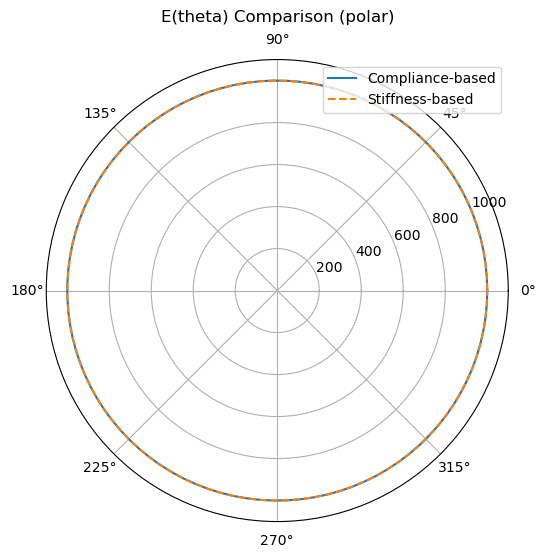

In [49]:
# plane stress
C1 = (E / (1 - nu**2)) * np.array([[1, nu, 0],
                                   [nu, 1, 0],
                                   [0, 0, (1 - nu) / 2]])
test_E_theta(C1)

* Plane strain conditions:
$$
\boldsymbol C = \frac{E(1-\nu)}{(1+\nu)(1-2\nu)} \begin{bmatrix}
1 & \frac{\nu}{1-\nu} & 0 \\
\frac{\nu}{1-\nu} & 1 & 0 \\
0 & 0 & \frac{1-2\nu}{2(1-\nu)}
\end{bmatrix}
$$
It should be noted that for plane strain cases, the elastic modulus in the principal directions are different from the input Young's modulus due to the constraint in the out-of-plane direction. The theoretical elastic modulus values in the principal directions can be computed as:
$$
E_{\text{eff}} = \frac{E}{1-\nu^2}
$$

Max absolute difference between two methods:  6.821210263296962e-13
Max value of E(theta):  1098.9010989010992
Min value of E(theta):  1098.9010989010987


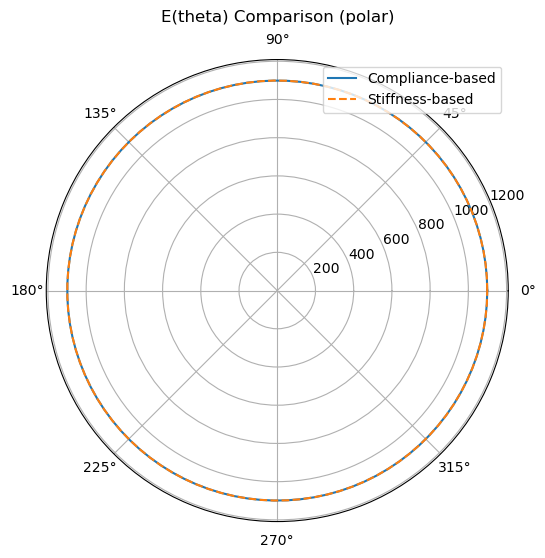

Theoretical principal elastic moduli for plane strain case: 1098.901098901099


In [50]:
# plane strain
C11 = E*(1-nu)/((1+nu)*(1-2*nu))
C12 = E*nu/((1+nu)*(1-2*nu))
C = np.array([
            [C11, C12, 0.0],
            [C12, C11, 0.0], 
            [0.0, 0.0, (C11-C12)/2]
            ])
test_E_theta(C)
print("Theoretical principal elastic moduli for plane strain case:", E / ((1 - nu**2)))

### Orthotropic material

The orthotropic material has two vertical symmetry lines/planes, which leads to zero values for $C_{16}$ and $C_{26}$. The stiffness matrix is given by 
$$
\boldsymbol C = \begin{bmatrix}
C_{11} & C_{12} & 0 \\
C_{12} & C_{22} & 0 \\
0 & 0 & C_{66}
\end{bmatrix}
$$
which has four independent parameters: $C_{11}$, $C_{12}$, $C_{22}$, and $C_{66}$.

Max absolute difference between two methods:  2.842170943040401e-14
Max value of E(theta):  54.53921404937993
Min value of E(theta):  37.5


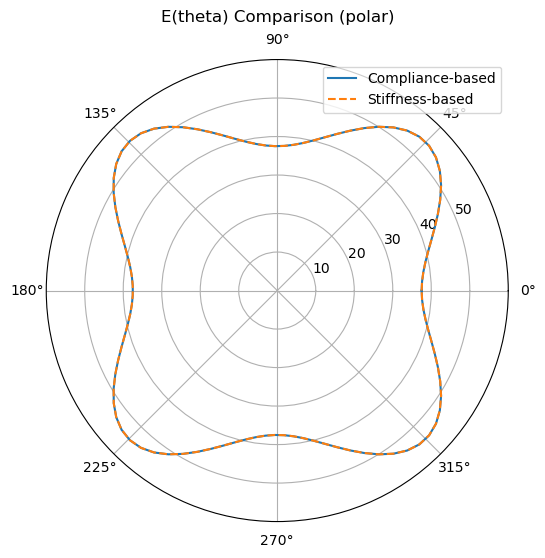

In [59]:
# orthotropic case I
C3 = np.array([[40.0, 10.0, 0.0],
               [10.0, 40.0, 0.0],
               [0.0, 0.0, 30.0]])
test_E_theta(C3)

Some special cases of orthotropic materials include:

* Tetragonal material

The tetragonal material also has two vertical symmetry planes, but with an additional constraint that $C_{11} = C_{22}$. The stiffness matrix is given by
$$
\boldsymbol C = \begin{bmatrix}
C_{11} & C_{12} & 0 \\
C_{12} & C_{11} & 0 \\
0 & 0 & C_{66}
\end{bmatrix}
$$